# Linear Absorption Spectrum
This notebook covers, how to use the Wannier90 tight binding file format and its non-orthogonal version to calculate a linear absorption spectrum

Load the tight binding file with matrix elements and lattice information

In [27]:
import sys
from pathlib import Path
project_root = Path.cwd().parent  # Current working directory
sys.path.insert(0, str(project_root / "src"))

In [28]:
from tb_calculations.parse_and_FT import read_tb
lattice, cells, degeneracies, Hr, Sr, Rr = read_tb(str(project_root/ "data/seedname_mos2/seedname_tb.dat"))

Up to 4 unit cell shifts
position operator does not fulfill symmetry requirement by up to 1.0427167129734016e-08


Set momentum space grid on which calculation is carried out

In [32]:

from tb_calculations.utils import k_grid, k_grid_bz
kFrac = k_grid(n_points=(40,40,1))

Calculate polarizability tensor. Number of valence bands, broadening eta and frequency range must be set manually

In [33]:

from tb_calculations.extract_observables import absorption_spec_lee
valence_num = 9
omega1, sigma1 = absorption_spec_lee(Sr=Sr, Hr=Hr, Rr=Rr, kFrac=kFrac, lattice=lattice, cells=cells, degeneracies=degeneracies, valence_num=valence_num, eta_eV=0.1, range_omega=(0,10))

Max x-component 0.6033644875510201
Max y-component 0.6221078182858035
Max z-component 0.5937044850870254
Bloch-basis momentum hermitian up to 9.27168920888424e-09
Fermi level at -4.598731591794692


Create plot

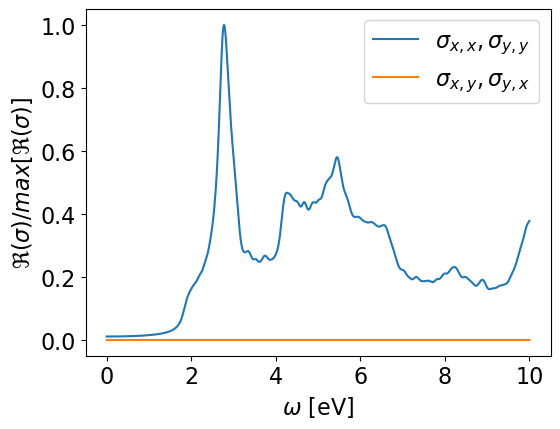

In [34]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16})
plt.rcParams['savefig.bbox'] = 'tight'
fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(omega1, sigma1[:,0,0], label=r'$\sigma_{x,x}, \sigma_{y,y}$')
ax.plot(omega1, sigma1[:,0,1], label=r'$\sigma_{x,y}, \sigma_{y,x}$')
# ax.plot(omega1, sigma1[:,1,1], label=r'$\sigma_{y,y}$')
# ax.plot(omega1, sigma1[:,1,0]) 
ax.set_xlabel(r"$\omega \ [\mathrm{eV}]$")
ax.set_ylabel(r"$\Re{(\sigma)}/ max[\Re{(\sigma)}]$")
ax.legend(loc='upper right')
plt.show()